In [ ]:
#Course : DSC640

#Name : Tejashri Bhilare

#Week 3 and 4

#Week 3 and 4 exercise : White House logs

Step 1: Import Necessary Libraries

In [1]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configure visualization styles
sns.set_theme(style="whitegrid")


Step 2: Load and Combine the Data

In [2]:
# Load datasets
file_2021 = "C:/Users/Teju/Downloads/Dataset/2021_WAVES-ACCESS-RECORDS White House.csv"
file_2022_jan = "C:/Users/Teju/Downloads/Dataset/2022.01_WAVES-ACCESS-RECORDS.csv"
file_2022_aug = "C:/Users/Teju/Downloads/Dataset/2022.08_WAVES-ACCESS-RECORDS.csv"
file_2023_jan = "C:/Users/Teju/Downloads/Dataset/2023.01_WAVES-ACCESS-RECORDS.csv"
file_2023_dec = "C:/Users/Teju/Downloads/Dataset/2023.12_WAVES-ACCESS-RECORDS.csv"

# Load the data into dataframes
data_2021 = pd.read_csv(file_2021)
data_2022_jan = pd.read_csv(file_2022_jan)
data_2022_aug = pd.read_csv(file_2022_aug)
data_2023_jan = pd.read_csv(file_2023_jan)
data_2023_dec = pd.read_csv(file_2023_dec)

# Combine datasets into a single dataframe
all_data = pd.concat([data_2021, data_2022_jan, data_2022_aug, data_2023_jan, data_2023_dec], ignore_index=True)

# Standardize column names and parse dates
all_data.columns = all_data.columns.str.strip().str.lower()
all_data['appt_start_date'] = pd.to_datetime(all_data['appt_start_date'], errors='coerce')

# Create 'month' and 'year' columns
all_data['month'] = all_data['appt_start_date'].dt.month
all_data['year'] = all_data['appt_start_date'].dt.year

# Drop rows with missing or invalid dates
all_data = all_data.dropna(subset=['appt_start_date'])

print(all_data.head())


C:\Users\Teju\AppData\Local\Temp\ipykernel_11944\1088558886.py:12: DtypeWarning: Columns (7,8) have mixed types. Specify dtype option on import or set low_memory=False.
  data_2023_jan = pd.read_csv(file_2023_jan)
C:\Users\Teju\AppData\Local\Temp\ipykernel_11944\1088558886.py:13: DtypeWarning: Columns (7,8) have mixed types. Specify dtype option on import or set low_memory=False.
  data_2023_dec = pd.read_csv(file_2023_dec)


  namelast namefirst namemid     uin  bdgnbr access_type               toa  \
0   AAKHUU  BOLORMAA       N  U38116     NaN          VA               NaN   
1   AASSAR       MIA       L  U37794     NaN          VA  12/17/2021 12:23   
2   ABALOS    JANILA       L  U38186     NaN          VA               NaN   
3  ABARCAR      KARA       N  U37879     NaN          VA  12/19/2021 17:25   
4   ABBOTT   NICOLAS       P  U36630     NaN          VA               NaN   

   poa  tod  pod  ... visitee last name visitee first name meeting location  \
0  NaN  NaN  NaN  ...               NaN                NaN              NaN   
1  NaN  NaN  NaN  ...               NaN                NaN              NaN   
2  NaN  NaN  NaN  ...               NaN                NaN              NaN   
3  NaN  NaN  NaN  ...               NaN                NaN              NaN   
4  NaN  NaN  NaN  ...               NaN                NaN              NaN   

  meeting room  caller last name caller first name calle

Step 3: Visualization - Visitors Per Month (Bar Chart)

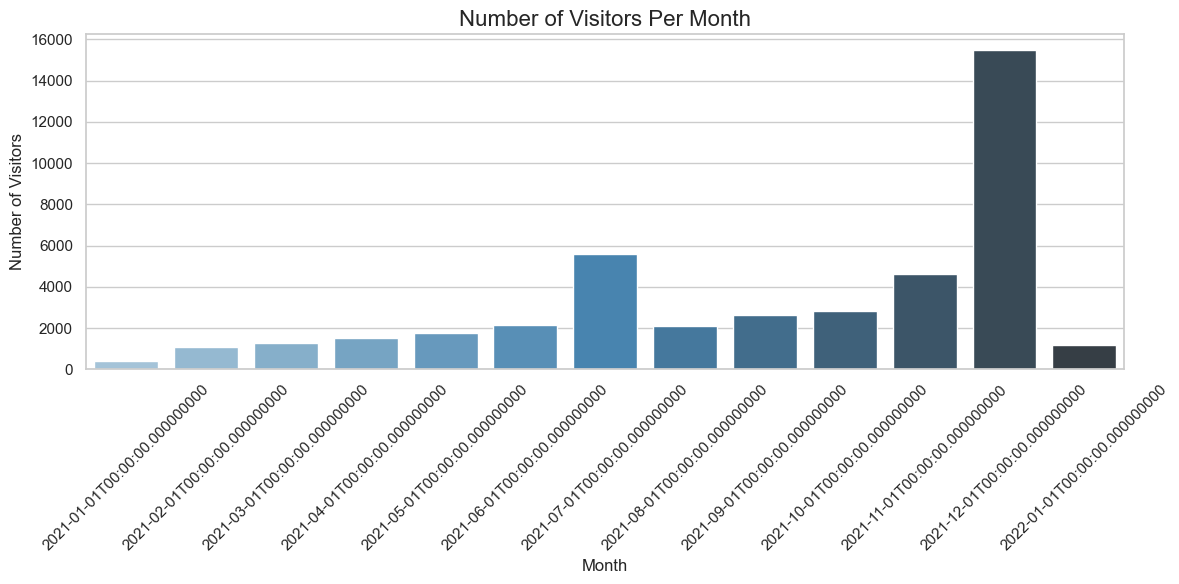

<Figure size 640x480 with 0 Axes>

In [3]:
# Group by year and month
visitors_per_month = all_data.groupby(['year', 'month']).size().reset_index(name='count')
visitors_per_month['date'] = pd.to_datetime(visitors_per_month[['year', 'month']].assign(day=1))

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(data=visitors_per_month, x='date', y='count', palette='Blues_d')
plt.title('Number of Visitors Per Month', fontsize=16)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Number of Visitors', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig('bar_chart_visitor_trend.png', dpi=300)
plt.show()
plt.clf()

In [4]:
print(all_data.columns)

Index(['namelast', 'namefirst', 'namemid', 'uin', 'bdgnbr', 'access_type',
       'toa', 'poa', 'tod', 'pod', 'appt_made_date', 'appt_start_date',
       'appt_end_date', 'appt_cancel_date', 'total_people', 'last_updatedby',
       'post', 'lastentrydate', 'terminal_suffix', 'visitee_namelast',
       'visitee_namefirst', 'meeting_loc', 'meeting_room', 'caller_name_last',
       'caller_name_first', 'caller_room', 'releasedate', 'last name',
       'first name', 'middle initial', 'access type', 'appointment made date',
       'appointment start date', 'appointment end date',
       'appointment cancel date', 'total people', 'last updated by',
       'last entry date', 'terminal suffix', 'visitee last name',
       'visitee first name', 'meeting location', 'meeting room',
       'caller last name', 'caller first name', 'caller room', 'release date',
       'month', 'year'],
      dtype='object')


 Visualization - Total Visitors Over Time (Line Chart)

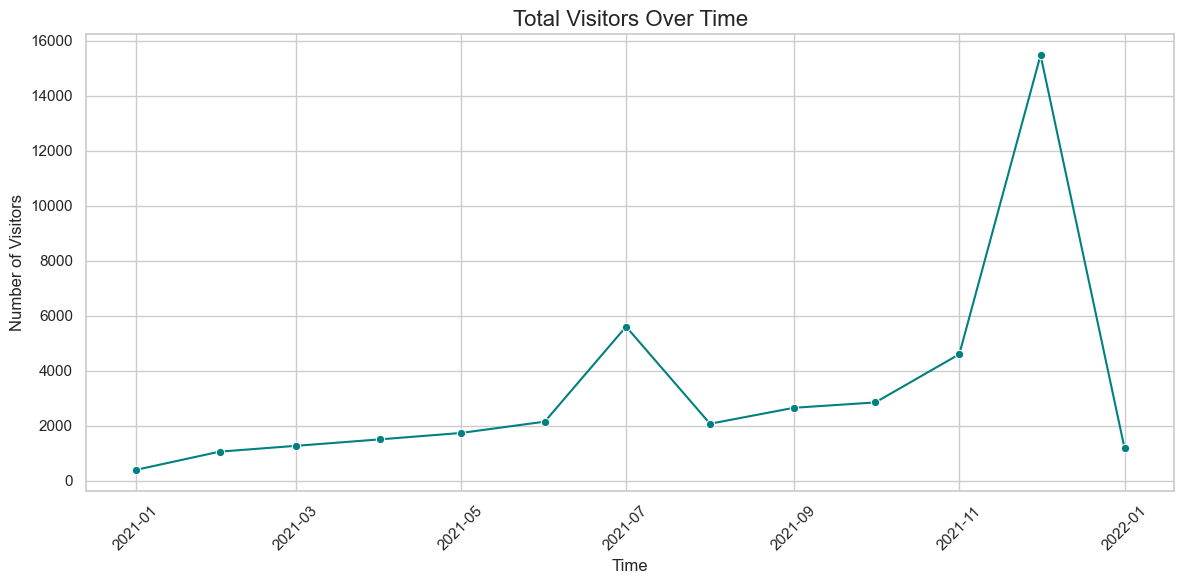

<Figure size 640x480 with 0 Axes>

In [5]:
# Total visitors by month
line_data = visitors_per_month.copy()

# Plot
plt.figure(figsize=(12, 6))
sns.lineplot(data=line_data, x='date', y='count', marker='o', color='teal')
plt.title('Total Visitors Over Time', fontsize=16)
plt.xlabel('Time', fontsize=12)
plt.ylabel('Number of Visitors', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()


plt.savefig('line_chart_visitor_trend.png', dpi=300)
plt.show()
plt.clf()


Visualization - Cumulative Visitors (Step Chart)

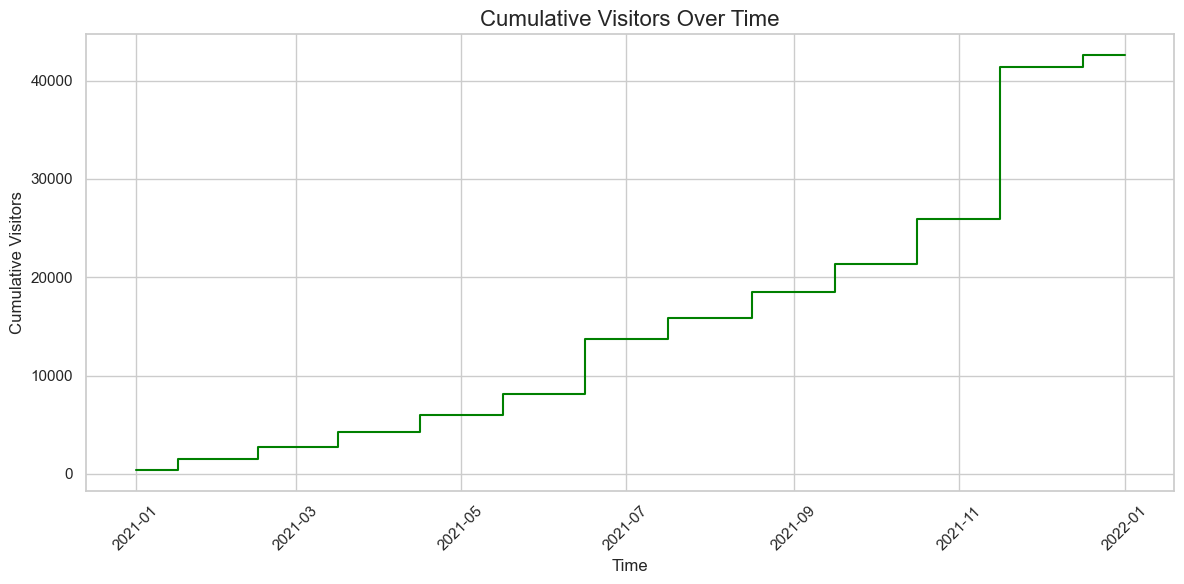

<Figure size 640x480 with 0 Axes>

In [6]:
# Calculate cumulative count
visitors_per_month['cumulative_count'] = visitors_per_month['count'].cumsum()

# Plot step chart
plt.figure(figsize=(12, 6))
plt.step(visitors_per_month['date'], visitors_per_month['cumulative_count'], where='mid', color='green')
plt.title('Cumulative Visitors Over Time', fontsize=16)
plt.xlabel('Time', fontsize=12)
plt.ylabel('Cumulative Visitors', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig('step_chart_visitor_trend.png', dpi=300)
plt.show()
plt.clf()


Column Chart: Comparing Most Frequently Used Meeting Locations

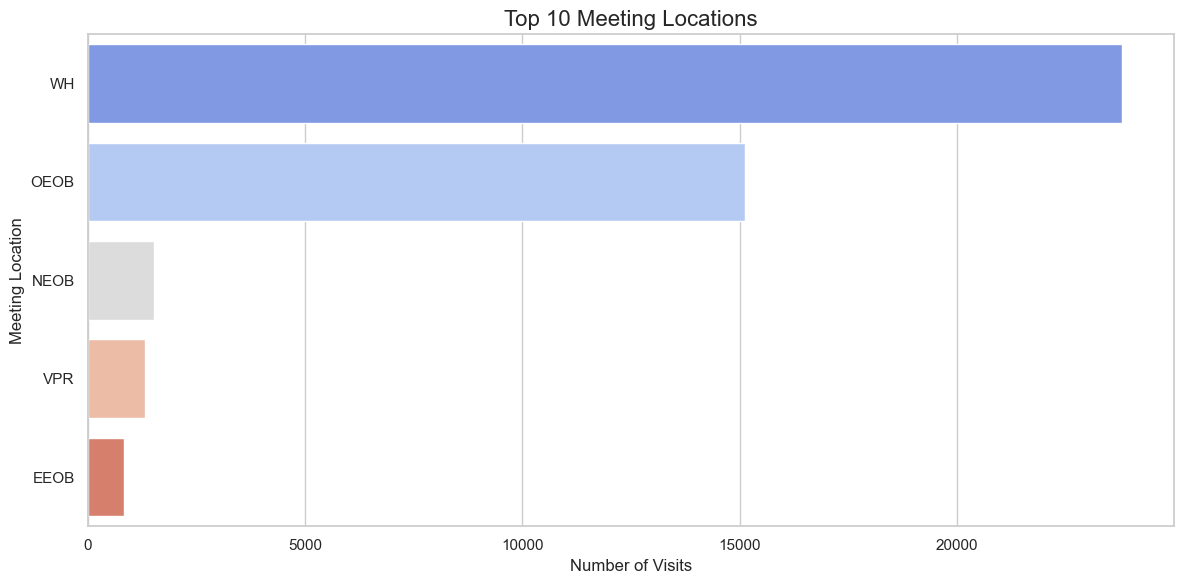

<Figure size 640x480 with 0 Axes>

In [7]:
# Count most frequent meeting locations
top_locations = all_data['meeting_loc'].value_counts().head(10).reset_index()
top_locations.columns = ['location', 'count']

# Plot column chart
plt.figure(figsize=(12, 6))
sns.barplot(data=top_locations, x='count', y='location', palette='coolwarm')
plt.title('Top 10 Meeting Locations', fontsize=16)
plt.xlabel('Number of Visits', fontsize=12)
plt.ylabel('Meeting Location', fontsize=12)
plt.tight_layout()

plt.savefig('column_chart_visitor_trend.png', dpi=300)
plt.show()
plt.clf()

Scatterplot with Time: Mapping arrival trends of only 10 visitors 

C:\Users\Teju\AppData\Local\Temp\ipykernel_11944\1971889231.py:9: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(


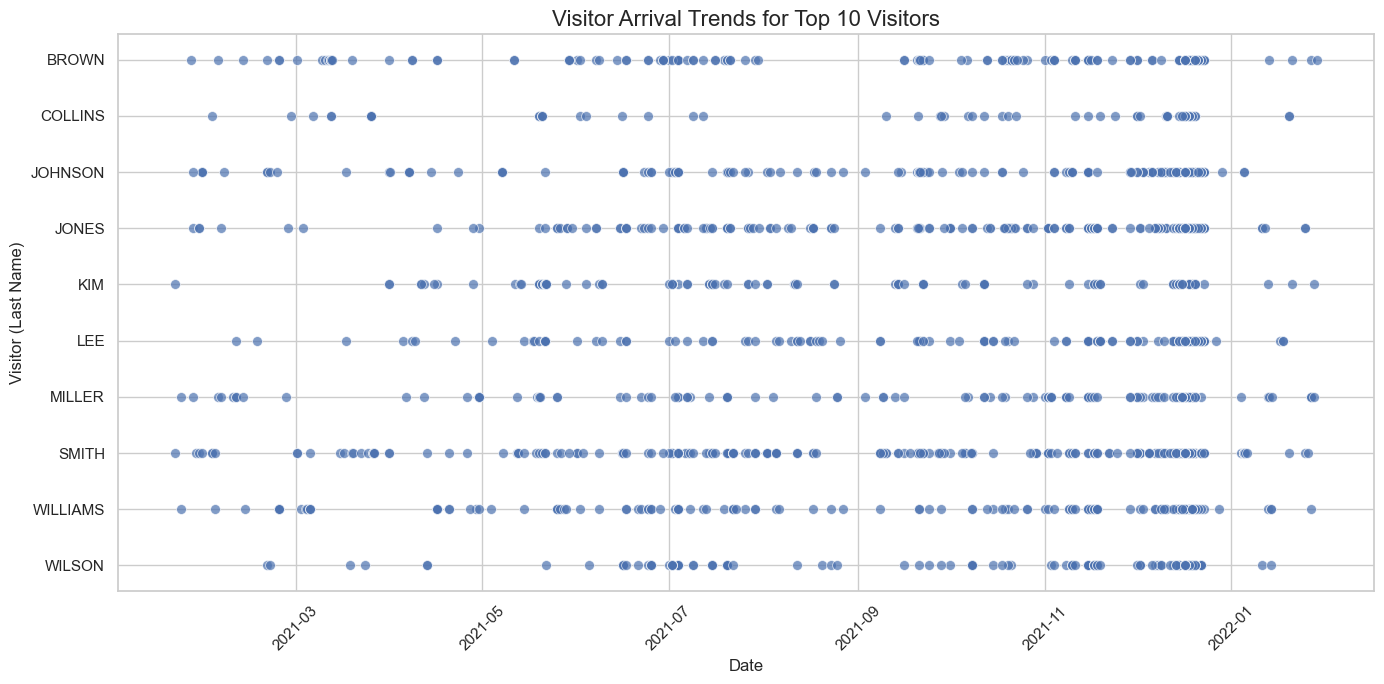

<Figure size 640x480 with 0 Axes>

In [8]:
# Get the top 10 visitors based on the number of visits
top_10_visitors = all_data['namelast'].value_counts().head(10).index

# Filter data for the top 10 visitors
filtered_data = all_data[all_data['namelast'].isin(top_10_visitors)]

# Plot scatterplot with time for top 10 visitors
plt.figure(figsize=(14, 7))
sns.scatterplot(
    data=filtered_data,
    x='appt_start_date',
    y='namelast',
    alpha=0.7,
    s=50,
    palette='tab10'
)
plt.title('Visitor Arrival Trends for Top 10 Visitors', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Visitor (Last Name)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig('scatterplot_visitor_trend.png', dpi=300)
plt.show()
plt.clf()


Stacked Bar Chart with Time (Top 10 Meeting Locations)


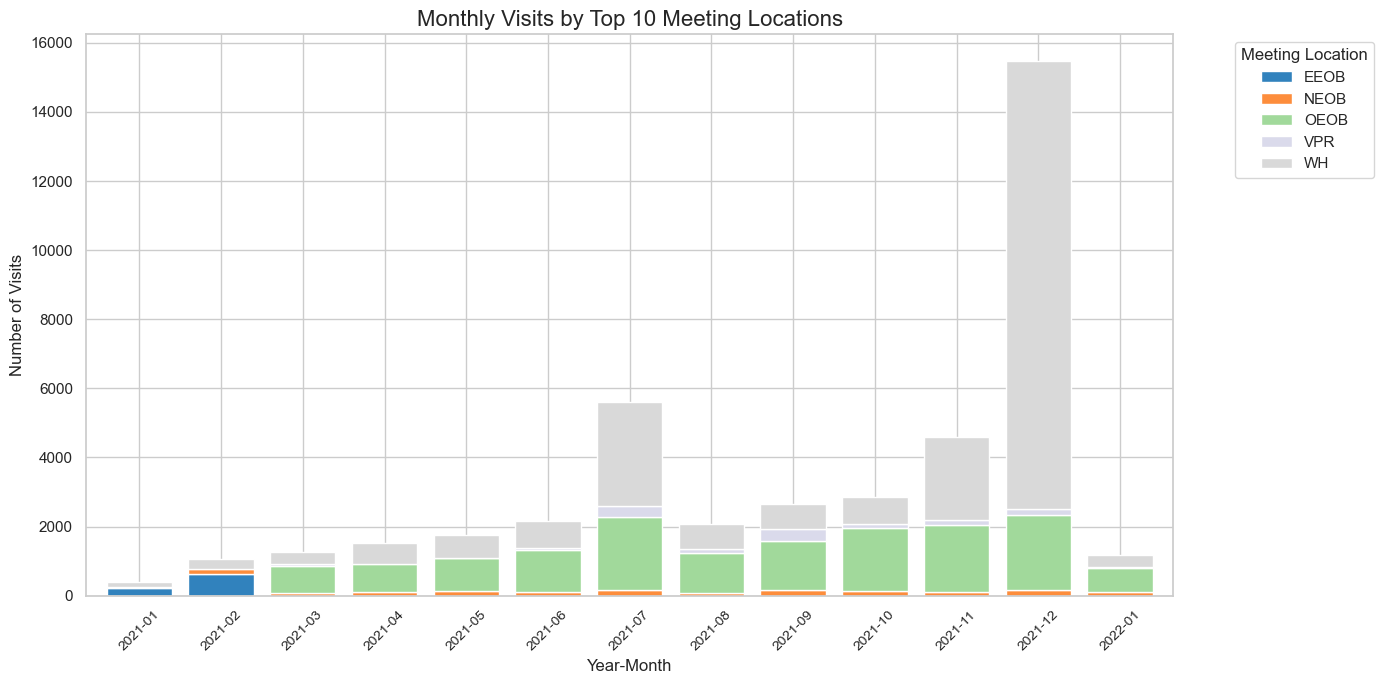

<Figure size 640x480 with 0 Axes>

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# Group data by year, month, and meeting location
stacked_data = all_data.groupby(['year', 'month', 'meeting_loc']).size().reset_index(name='count')

# Select the top 10 most frequent meeting locations
top_locations = stacked_data.groupby('meeting_loc')['count'].sum().nlargest(10).index
stacked_data = stacked_data[stacked_data['meeting_loc'].isin(top_locations)]

# Pivot the data to prepare for the stacked bar chart
stacked_pivot = stacked_data.pivot(index=['year', 'month'], columns='meeting_loc', values='count').fillna(0)

# Create the stacked bar chart
stacked_pivot.plot(
    kind='bar',
    stacked=True,
    figsize=(14, 7),
    colormap='tab20c',
    width=0.8
)

# Format the x-axis
plt.title('Monthly Visits by Top 10 Meeting Locations', fontsize=16)
plt.xlabel('Year-Month', fontsize=12)
plt.ylabel('Number of Visits', fontsize=12)
plt.xticks(
    ticks=range(len(stacked_pivot.index)),
    labels=[f'{int(year)}-{int(month):02d}' for year, month in stacked_pivot.index],
    rotation=45,
    fontsize=10
)
plt.legend(title='Meeting Location', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plt.savefig('stacked_bar_chart_visitor_trend.png', dpi=300)
plt.show()
plt.clf()
